# Phase 2 (notebook) — Analyse de sentiment des reclamations

Remplace `phase2_sentiment.py`. Modele : `cardiffnlp/twitter-xlm-roberta-base-sentiment-multilingual`
(multilingue, entraine sur du texte social informel, 3 classes negative/neutral/positive),
utilise en inference directe (zero-shot) — aucune donnee labellisee disponible
pour entrainer un modele supervise.

Applique sur `texte_masque` (nettoye, PII masquee, non lemmatise) : un modele
transformer s'appuie sur l'ordre des mots, que la lemmatisation detruirait.

In [2]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, ".")
sys.path.insert(0, "..")

import phase2_sentiment as p2
from viz_utils import plot_full_distribution, plot_stacked_share

PROJECT_DIR = Path("..").resolve()
PHASE1_CSV = PROJECT_DIR / "reclamations_phase1.csv"
PHASE2_CSV = PROJECT_DIR / "reclamations_phase2.csv"

plt.rcParams["figure.dpi"] = 100

df1 = pd.read_csv(PHASE1_CSV, low_memory=False)
print(f"{len(df1)} tickets charges depuis {PHASE1_CSV.name}")

/home/gauss/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


8284 tickets charges depuis reclamations_phase1.csv


## 1. Inference du sentiment

Le modele transformer (CPU) prend plusieurs minutes sur l'ensemble du corpus
-> on charge le resultat mis en cache s'il existe deja, sinon on relance
l'inference complete (code ci-dessous, identique a `phase2_sentiment.py`).

In [4]:
if PHASE2_CSV.exists():
    print(f"Cache trouve : {PHASE2_CSV.name} -> chargement (evite de relancer l'inference transformer).")
    df2 = pd.read_csv(PHASE2_CSV, low_memory=False)
else:
    print("Pas de cache : inference du modele de sentiment (peut prendre plusieurs minutes sur CPU)...")
    df2 = p2.run_sentiment(df1, text_col="texte_masque")
    df2.to_csv(PHASE2_CSV, index=False)
    print(f"Ecrit : {PHASE2_CSV.name}")

df2[["texte_masque", "sentiment_label", "sentiment_score"]].head(5)

Cache trouve : reclamations_phase2.csv -> chargement (evite de relancer l'inference transformer).


,texte_masque,sentiment_label,sentiment_score
0,RECLAMATION. Le <DATE> à 18heures 35 minutes e...,neutral,0.6047
1,transfert vers orange non abouti,neutral,0.5807
2,Beneficiary error. I made a transaction of <MO...,negative,0.5008
3,erreur de bénéficiaire. Lors d'une transaction...,negative,0.9510
4,Cela fait maintenant plusieurs jours que j'ai ...,negative,0.7821


## 2. Distribution globale du sentiment

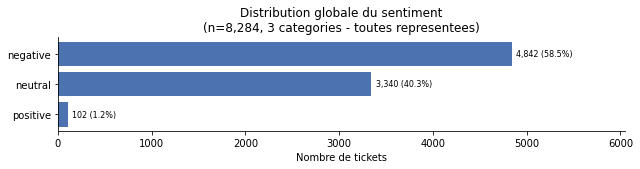

In [6]:
_ = plot_full_distribution(df2["sentiment_label"].fillna("non calcule").replace("", "non calcule"), "Distribution globale du sentiment")
plt.show()

## 3. Sentiment par categorie de reclamation — TOUTES les categories

L'ancien rapport texte ne listait que 10 categories sur 15 (celles sous 15
tickets etaient omises). Ici, les 15 categories restent visibles, y compris
`Feature request` (2 tickets) ou `Card issue` (2 tickets).

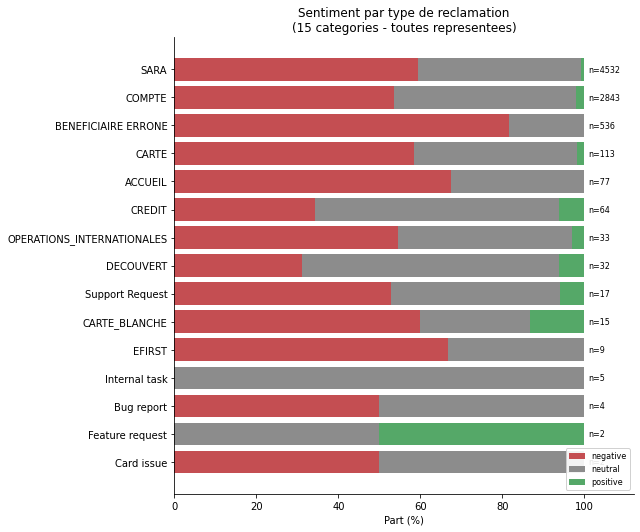

In [8]:
df2_valid = df2[df2["sentiment_label"].notna() & (df2["sentiment_label"] != "")]
_ = plot_stacked_share(
    df2_valid, "ticket_type_name", "sentiment_label",
    "Sentiment par type de reclamation",
    colors={"negative": "#C44E52", "neutral": "#8C8C8C", "positive": "#55A868"},
)
plt.show()

## 4. Sentiment par canal — TOUS les canaux

Idem : l'ancien rapport s'arretait a 5 canaux sur 7 (`instagram` et `email`,
1-2 tickets chacun, avaient disparu).

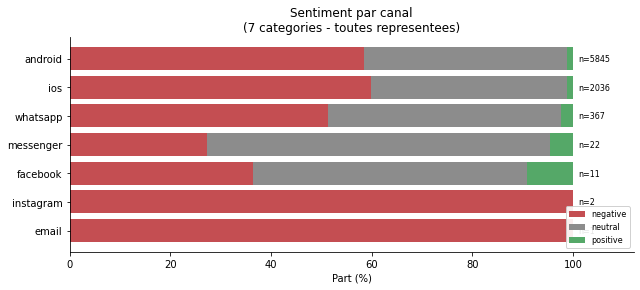

In [10]:
_ = plot_stacked_share(
    df2_valid, "channel", "sentiment_label",
    "Sentiment par canal",
    colors={"negative": "#C44E52", "neutral": "#8C8C8C", "positive": "#55A868"},
)
plt.show()

## 5. Score de confiance du modele

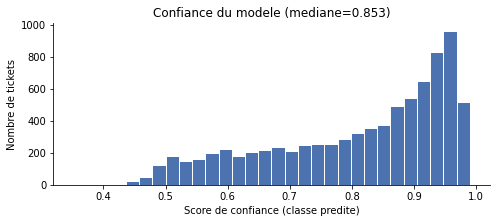

In [12]:
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(df2_valid["sentiment_score"].dropna(), bins=30, color="#4C72B0", edgecolor="white")
ax.set_xlabel("Score de confiance (classe predite)")
ax.set_ylabel("Nombre de tickets")
ax.set_title(f"Confiance du modele (mediane={df2_valid['sentiment_score'].median():.3f})")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
plt.show()